# Track Statistics Analysis

**Author:** Mingshi Yang (mingshi3@illinois.edu)  
**Date:** 2026-06-22

**Project:**  
*Characteristics of Midlatitude Cyclones under Climate Change in a Global Storm-Resolving Model*

**Description:**  
Created during Revision 1, this notebook generates Figures 1–2 and associated Supplementary Information (SI)
figures S1-S4, presenting general cyclone track statistics including frequency,
duration, seasonality, and density with large scale circulation information. 
Selected metrics are compared against corresponding statistics derived from the ERA5 reanalysis.


In [13]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from matplotlib import colors
from numpy import dtype
import xarray as xr
from scipy import stats
from datetime import date
import collections
import os
from scipy.stats import circmean
import pickle
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [14]:
track_dir = '/data/keeling/a/mingshi3/c/xshield/Midlatitude-Cyclone-in-X-SHiELD/data/tracks'
u200_dir = '/data/keeling/a/mingshi3/c/xshield/Midlatitude-Cyclone-in-X-SHiELD/data/u200'

In [15]:
R = 6371 # radius of earth in km used to calculate density function

In [16]:
# helper functions

def subset_by_month(data, months):
    months_str = [str(month).zfill(2) for month in months]
    dates_str = np.int64(data[:, 0]).astype(str)
    months_data = np.array([date[4:6] for date in dates_str])
    # Find the indices where the month is in the list of months
    indices = np.isin(months_data, months_str)
    # Filter the array based on these indices
    subset_data = data[indices].copy()
    return subset_data

def filterlat(data,nlat,nlon,v_lat):
    data2 = np.ones((nlat,nlon))
    j = len(data[0])
    for i in range(len(data)):
        w = int(min(j,1/np.cos(np.deg2rad(v_lat[i]))))
        #print(w)
        arr = np.append(data[i],data[i])
        #print(arr)
        arr2 = np.ones_like(data[i])
        for k in range(j):
            arr2[(k+int(j/2))%j] *= np.nanmean(arr[k+int(j/2)-w:k+int(j/2)+w+1])
            #print(k+int(j/2)-w,k+int(j/2)+w+1)
        arr2[np.isnan(data[i])] = np.nan
        data2[i] *= arr2
    return data2

In [17]:
experiments = [ 'PIRE',
                'PIRE_CO2_1270ppmv',
                'PIRE_PLUS_4K',
                'PIRE_PLUS_4K_CO2_1270ppmv']

experiments_display = [ 'CTRL   ',
                '+CO₂   ',
                '+4K    ',
                '+4K+CO₂']

expnames = ['ERA5   '] + experiments_display

colorlist = ['gray','black','C0','C1','C3']

all_tracks files are created by concating all tracks produced by Crawford et al. (2021) to a single text file
there is a paired index file noting beginning and ending line numbers of each track

In [18]:
# x-shield data
data = []
idx = []
for exp in experiments:
    data.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Tracks.txt'))
    idx.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Indexes.txt'))

In [19]:
# compare with ERA5 data
TK = np.loadtxt(f'{track_dir}/TK2Y-ERA5/All_Tracks.txt')
TKIDX = np.loadtxt(f'{track_dir}/TK2Y-ERA5/All_Indexes.txt')

Figure 1 and associated SI figures

In [20]:
# timesteps in tracks are in YYYYMMDDHH format
# to produce Figures S3-S4, modify starting time and ending time in this cell
# - e.g., 2020 only: time_begin = 2020 and time_end = 2020
time_begin = 2020 # inclusive
time_end = 2021 # inclusive
# they will be multipled by 1000000 as selection range of timesteps in tracks

In [21]:
# crawford era5 track
tk2 = TK[(TK[:,0]>(time_begin*1000000))&(TK[:,0]<((time_end+1)*1000000)),:] # ERA5 in 2020-2021
tk2 = tk2[(tk2[:,1] < 65)&(tk2[:,1] >= 30)] # midlatitude cyclone criteria

# monthly frequency used in figure 1
mon = tk2[:,0] // 10000 % 100 # month identifier
histd_era5, bin_edges = np.histogram(mon,bins=np.linspace(0.5,12.5,13),density=False)

MC sample size 29884 0.999999853067374


/tmp/ipykernel_3513449/1440493373.py:49: RuntimeWarning: divide by zero encountered in divide
  axes[0].plot(x/mask, y/mask, color=colorlist[0], alpha=0.6, linestyle='--')


ERA5 CTRL    TtestResult(statistic=-23.184164222092637, pvalue=2.22781592581323e-118, df=59074.0)
ERA5 CTRL    LeveneResult(statistic=52.027392959224365, pvalue=5.538612078085421e-13)
MC sample size 29192 0.9999998396963169
mean: +CO₂    993.9803089454784 CTRL    993.7714881094136
1 CTRL    +CO₂    TtestResult(statistic=1.9680732287088034, pvalue=0.049064496455928724, df=56482.0)
1 CTRL    +CO₂    LeveneResult(statistic=4.72957438197612, pvalue=0.02965235630232653)


/tmp/ipykernel_3513449/1440493373.py:84: RuntimeWarning: divide by zero encountered in divide
  axes[0].plot(x/mask, y/mask, linestyle='--', color=colorlist[i+1], alpha=0.6)


MC sample size 27292 0.9999998659306808
mean: +4K     993.6882969646826 CTRL    993.7714881094136
2 CTRL    +4K     TtestResult(statistic=-0.718808634647395, pvalue=0.4722619769965887, df=53484.0)
2 CTRL    +4K     LeveneResult(statistic=96.96751699613998, pvalue=7.37030516987565e-23)


...

MC sample size 24294 0.99999968717824
mean: +4K+CO₂ 994.0095132080772 CTRL    993.7714881094136
3 CTRL    +4K+CO₂ TtestResult(statistic=2.1069814427186313, pvalue=0.03512377919471078, df=54099.0)
3 CTRL    +4K+CO₂ LeveneResult(statistic=34.30894421572865, pvalue=4.729275654067684e-09)


/tmp/ipykernel_3513449/1440493373.py:84: RuntimeWarning: divide by zero encountered in divide
  axes[0].plot(x/mask, y/mask, linestyle='--', color=colorlist[i+1], alpha=0.6)


MC sample size 24909 0.9999997684751855


/tmp/ipykernel_3513449/1440493373.py:84: RuntimeWarning: divide by zero encountered in divide
  axes[0].plot(x/mask, y/mask, linestyle='--', color=colorlist[i+1], alpha=0.6)


ERA5 min dur: 1.0 | #TC: 2420
CTRL    min dur: 1.0 | #TC: 2464
+CO₂    min dur: 1.0 | #TC: 2294
1 CTRL    +CO₂    TtestResult(statistic=-1.256863747213877, pvalue=0.20886470036671795, df=4756.0)
1 CTRL    +CO₂    LeveneResult(statistic=1.0239313129393577, pvalue=0.31163977801837517)
+4K     min dur: 1.0 | #TC: 2029
2 CTRL    +4K     TtestResult(statistic=-1.6160980210177345, pvalue=0.10614336040301428, df=4491.0)
2 CTRL    +4K     LeveneResult(statistic=3.7546577740038494, pvalue=0.05272318709590032)
+4K+CO₂ min dur: 1.0 | #TC: 2065
3 CTRL    +4K+CO₂ TtestResult(statistic=-2.815199697601847, pvalue=0.004895764391480065, df=4527.0)
3 CTRL    +4K+CO₂ LeveneResult(statistic=7.30610972998469, pvalue=0.006897709315803548)
FREQ [2873 2641 2766 2783 2757 2205 1778 1794 1985 2344 2492 2774]
FREQ [2705 2474 2904 2554 2526 2299 1694 1619 1889 1874 2360 2394]
FREQ [2232 2285 2437 2115 2210 2027 1619 1654 1819 1738 1878 2280]
FREQ [2446 2130 2416 2437 2331 2095 1583 1679 1684 2131 1954 2023]


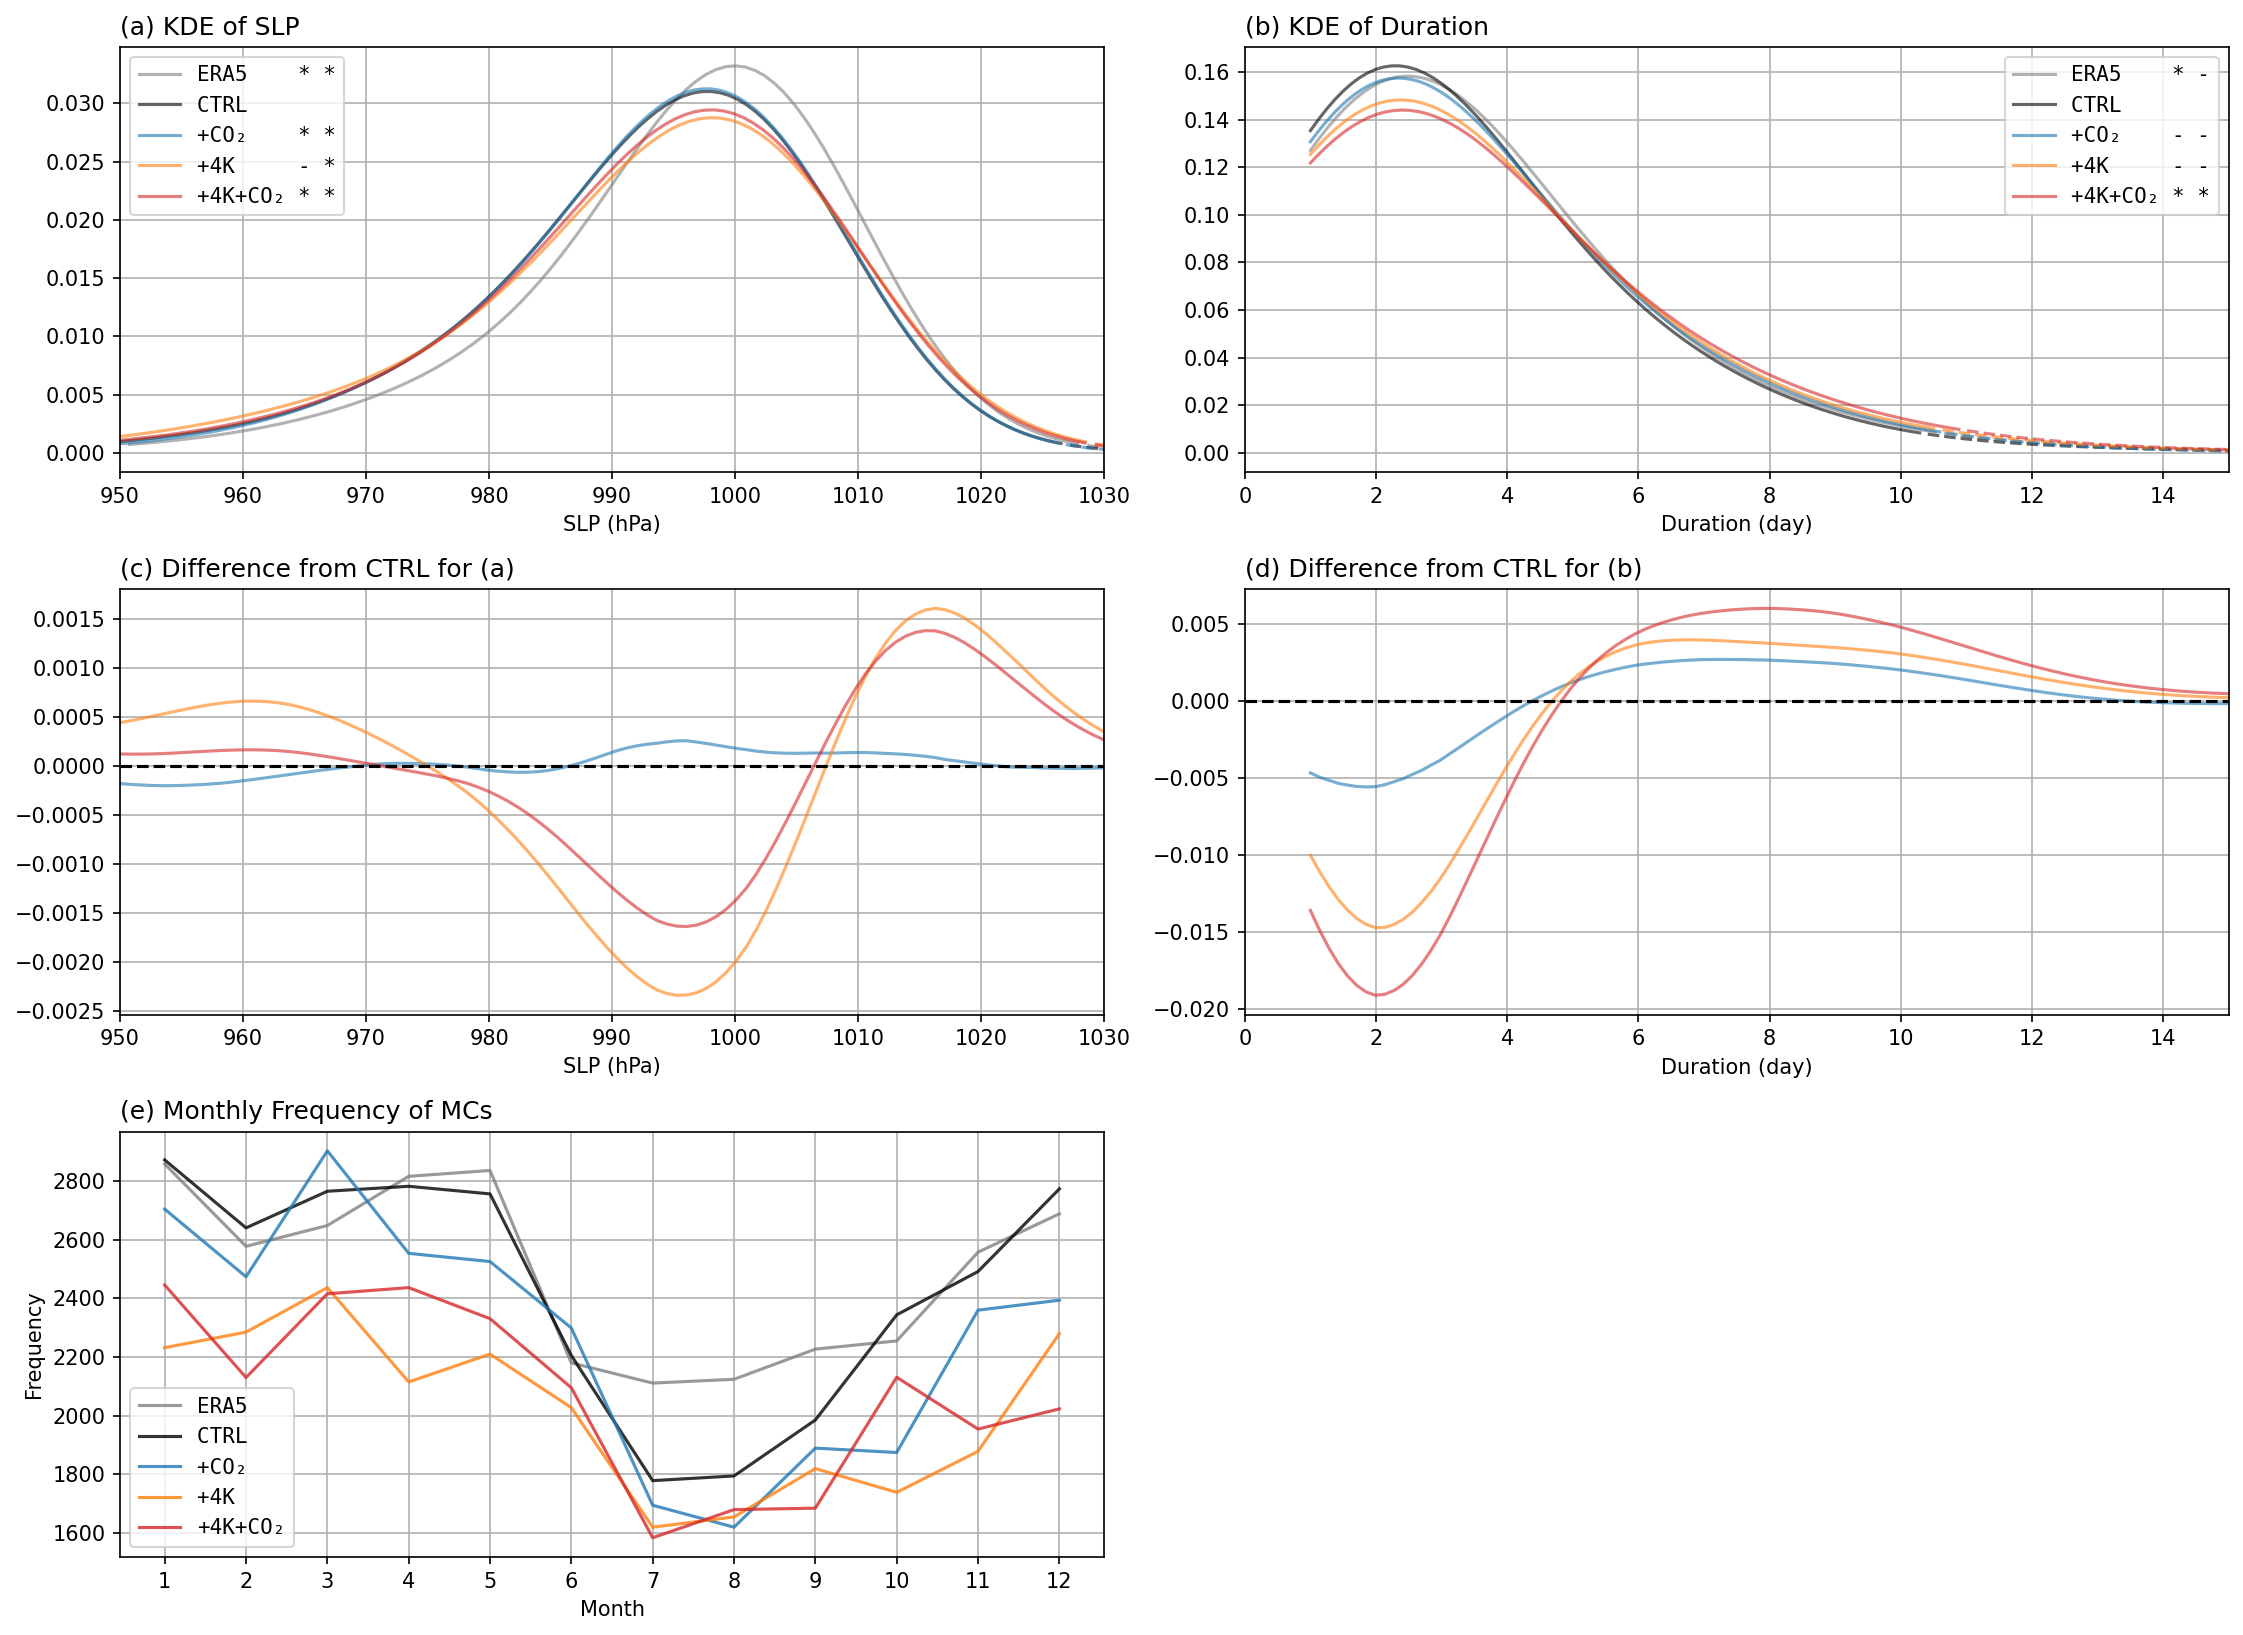

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

bw = 4 # increased smoothing for kde estimate (https://seaborn.pydata.org/generated/seaborn.kdeplot.html)
threshold = 20  # samples per hPa

alpha = 0.05 # significance level of t test

fig, axesall = plt.subplots(3, 2, figsize=(15, 11),dpi=150)
axes = axesall[:2, 0]
axes_dur = axesall[:2, 1]
ax_month = axesall[2, 0]
ax_winter = axesall[2,1]
#axesall[2, 1].axis('off')  # we won't use this panel

x_grid = np.linspace(920, 1040, 1201)
x_space = x_grid[1] - x_grid[0]

# Helper: extract KDE from seaborn
def get_kde_from_seaborn(data, bw_adjust, clip=None):
    temp_fig, temp_ax = plt.subplots()
    sns.kdeplot(data, bw_adjust=bw_adjust, ax=temp_ax, clip=clip, color='gray')  # dummy color
    line = temp_ax.lines[0]
    x, y = line.get_data()
    plt.close(temp_fig)
    return x, y

# ERA5 baseline
tk2_vals = tk2[:, -1]
sigs = ['-','-']
d = data[0]
d2 = d[(d[:, 0] > (time_begin*1000000)) & (d[:, 0] < ((time_end+1)*1000000)), :]
d2 = d2[:, -1][(d2[:, 1] < 65) & (d2[:, 1] >= 30)]
if stats.ttest_ind(d2, tk2_vals)[1] < alpha:
    sigs[0] = '*'
if stats.levene(d2, tk2_vals)[1] < alpha:
    sigs[1] = '*'

count = len(tk2_vals)
x, y = get_kde_from_seaborn(tk2_vals, bw)
x_space = x[1] - x[0]
print('MC sample size',count,y.sum() * x_space)
count_grid = y * count
#print(count_grid.sum())
mask = count_grid < threshold
axes[0].plot(x[~mask], y[~mask], label=expnames[0]+' '+' '.join(sigs), color=colorlist[0], alpha=0.6)
axes[0].plot(x/mask, y/mask, color=colorlist[0], alpha=0.6, linestyle='--')

kde0_x, kde0_y = None, None

for i, d in enumerate(data):
    d2 = d[(d[:, 0] > (time_begin*1000000)) & (d[:, 0] < ((time_end+1)*1000000)), :]
    d2 = d2[:, -1][(d2[:, 1] < 65) & (d2[:, 1] >= 30)]

    sigs = ['-','-']

    if i == 0:
        d0 = d2.copy()
        kde0_x, kde0_y = get_kde_from_seaborn(d0, bw)
        print('ERA5', expnames[i+1], stats.ttest_ind(d2, tk2_vals))
        print('ERA5', expnames[i+1], stats.levene(d2, tk2_vals))
        
        sigs = ['','']
    else:
        
        print('mean:',expnames[i+1],np.nanmean(d2),expnames[1],np.nanmean(d0))
        print(i, expnames[1], expnames[i+1], stats.ttest_ind(d2, d0))
        print(i, expnames[1], expnames[i+1], stats.levene(d2, d0))
        
        if stats.ttest_ind(d2, d0)[1] < alpha:
            sigs[0] = '*'
        if stats.levene(d2, d0)[1] < alpha:
            sigs[1] = '*'

    count = len(d2)
    x, y = get_kde_from_seaborn(d2, bw)
    x_space = x[1] - x[0]
    print('MC sample size', count,y.sum() * x_space)
    count_grid = y * count
    mask = count_grid < threshold
    axes[0].plot(x[~mask], y[~mask], label=expnames[i+1]+' '+' '.join(sigs), color=colorlist[i+1], alpha=0.6)
    axes[0].plot(x/mask, y/mask, linestyle='--', color=colorlist[i+1], alpha=0.6)

    if i > 0:
        # Interpolate for clean diff curve
        common_x = np.linspace(950, 1030, 100)
        y_interp = np.interp(common_x, x, y)
        y0_interp = np.interp(common_x, kde0_x, kde0_y)
        diff = y_interp - y0_interp
        axes[1].plot(common_x, diff, label=f'{expnames[i+1]}', color=colorlist[i+1], alpha=0.6)

# Styling
axes[0].legend(loc='upper left',prop={'family': 'monospace'})
axes[0].set_xlabel('SLP (hPa)')
axes[0].set_xlim(950, 1030)
axes[0].set_title("(a) KDE of SLP", loc='left')

axes[1].axhline(0, color='black', linestyle='--')
#axes[1].legend(loc='lower left')
axes[1].set_xlabel('SLP (hPa)')
axes[1].set_xlim(950, 1030)
axes[1].set_title("(c) Difference from CTRL for (a)", loc='left')

#plt.tight_layout()
#plt.show()

#axes_dur = axes[2:]
threshold = 20  # threshold for dashed line separation
bw = 4

test = stats.mannwhitneyu
test = stats.ttest_ind

# Helper: extract and mask kde
def get_kde_from_seaborn(data, bw_adjust, clip):
    temp_fig, temp_ax = plt.subplots()
    sns.kdeplot(data, bw_adjust=bw_adjust, clip=clip, ax=temp_ax, color='gray')
    line = temp_ax.lines[0]
    x, y = line.get_data()
    plt.close(temp_fig)
    return x, y

def plot_kde_with_mask(ax, x, y, label, color, count, threshold):
    x_space = x[1] - x[0]
    count_grid = y * count
    mask = count_grid < threshold
    ax.plot(x[~mask], y[~mask], label=label, color=color, alpha=0.6)
    ax.plot(x[mask], y[mask], linestyle='--', color=color, alpha=0.6)

# --- ERA5 Duration ---
dur_ref = []
dd = TK
nera=0
for im, ia in TKIDX:
    tk = dd[int(im):int(ia)].copy()
    tk = tk[((tk[:, 0] % 100) % 6) == 0]
    tk[:, -1] = np.gradient(tk[:, -1])
    step = tk[np.nanargmin(tk[:, -1])]
    if 30 <= step[1] < 65 and (time_begin*1000000) < step[0] < ((time_end+1)*1000000):
        dur_ref.append(len(tk) * 6 / 24)
        nera+=1
dur_ref = np.array(dur_ref)
print('ERA5 min dur:', dur_ref.min(), '| #TC:', nera)

x_ref, y_ref = get_kde_from_seaborn(dur_ref, bw_adjust=bw, clip=(1, np.inf))

# --- Models ---
for i, ii in enumerate(idx):
    dur = []
    dd = data[i]
    ntc = 0
    for im, ia in ii:
        tk = dd[int(im):int(ia)].copy()
        tk[:, -1] = np.gradient(tk[:, -1])
        step = tk[np.nanargmin(tk[:, -1])]
        if 30 <= step[1] < 65 and (time_begin*1000000) < step[0] < ((time_end+1)*1000000):
            dur.append((ia - im) * 6 / 24)
            ntc += 1
    dur = np.array(dur)
    if i == 0:
        dur_0 = dur.copy()
    print(f'{expnames[i+1]} min dur:', dur.min(), '| #TC:', ntc)

    x, y = get_kde_from_seaborn(dur, bw_adjust=bw, clip=(1, np.inf))
    if i == 0:
        x_0,y_0 = x.copy(),y.copy()

    sigs = ['-','-']
    if i > 0:
        print(i, expnames[1], expnames[i+1], test(dur_0, dur))
        print(i, expnames[1], expnames[i+1], stats.levene(dur_0, dur))
        if test(dur_0, dur)[1] < alpha:
            sigs[0] = '*'
        if stats.levene(dur_0, dur)[1] < alpha:
            sigs[1] = '*'
    else:
        #sigs = ['','']
        if test(dur_0, dur_ref)[1] < alpha:
            sigs[0] = '*'
        if stats.levene(dur_0, dur_ref)[1] < alpha:
            sigs[1] = '*'
        plot_kde_with_mask(axes_dur[0], x_ref, y_ref, label=expnames[0]+' '+' '.join(sigs), color=colorlist[0], count=len(dur_ref), threshold=threshold)
        sigs = ['','']
    plot_kde_with_mask(axes_dur[0], x, y, label=expnames[i+1]+' '+' '.join(sigs), color=colorlist[i+1], count=len(dur), threshold=threshold)

    # Difference plot
    if i > 0:
        
        common_x = np.linspace(1, 15, 100)
        y_interp = np.interp(common_x, x, y)
        y_0_interp = np.interp(common_x, x_0, y_0)
        diff = y_interp - y_0_interp
        axes_dur[1].plot(common_x, diff, label=expnames[i+1], color=colorlist[i+1], alpha=0.6)

# Styling
axes_dur[0].legend(loc='upper right',prop={'family': 'monospace'})
axes_dur[0].set_xlim(0, 15)
axes_dur[0].set_xlabel('Duration (day)')
axes_dur[0].set_title("(b) KDE of Duration", loc='left')

axes_dur[1].axhline(0, color='black', linestyle='--')
axes_dur[1].set_xlim(0, 15)
axes_dur[1].set_xlabel('Duration (day)')
axes_dur[1].set_title("(d) Difference from CTRL for (b)", loc='left')
#axes_dur[1].legend(loc='lower right')

for ax in axes:
    ax.grid()
for ax in axes_dur:
    ax.grid()


ax_month.plot(np.arange(1, 13), histd_era5, color=colorlist[0], label=expnames[0], alpha=0.8)

for i, d in enumerate(data):
    d2 = d[(d[:, 0] > (time_begin*1000000)) & (d[:, 0] < ((time_end+1)*1000000)), :]
    d2 = d2[(d2[:, 1] < 65) & (d2[:, 1] >= 30)]
    mon = d2[:, 0] // 10000 % 100
    histd, bin_edges = np.histogram(mon, bins=np.linspace(0.5, 12.5, 13), density=False)
    ax_month.plot(np.arange(1, 13), histd, linestyle='solid', label=expnames[i+1], color=colorlist[i+1], alpha=0.8)

    print('FREQ', histd)

ax_month.set_xticks(np.arange(1, 13))
ax_month.set_xlabel('Month')
ax_month.set_ylabel('Frequency')
ax_month.set_title('(e) Monthly Frequency of MCs', loc='left')
ax_month.grid()
ax_month.legend(prop={'family': 'monospace'})

# duration change in winter

def compute_duration_by_season(data_array, index_array, is_model=False):
    durations_winter = []
    durations_summer = []
    for im, ia in index_array:
        tk = data_array[int(im):int(ia)].copy()
        tk = tk[((tk[:, 0] % 100) % 6) == 0]
        tk[:, -1] = np.gradient(tk[:, -1])
        step = tk[np.nanargmin(tk[:, -1])]
        if 30 <= step[1] < 65 and (time_begin*1000000) < step[0] < ((time_end+1)*1000000):
            duration = (ia - im) * 6 / 24 if is_model else len(tk) * 6 / 24
            t_s0 = step[0]
            for time_year in range(time_begin, time_end+1):
                if (t_s0 >= time_year*1000000 and t_s0 < time_year*1000000 + 30000) \
                    or (t_s0 >= time_year*1000000 + 120000 and t_s0 < (time_year+1)*1000000): # Jan, Feb, Dec of current year
                    durations_winter.append(duration)
                elif (t_s0 >= time_year*1000000 + 60000 and t_s0 < time_year*1000000 + 90000): # June - August
                    durations_summer.append(duration)
            #if step[0] < 2020030000 or (step[0] >= 2020120000 and step[0] < 2021030000) or step[0] >= 2021120000:
            #    durations_winter.append(duration)
            #elif (2020060000 <= step[0] < 2020090000) and (2021060000 <= step[0] < 2021090000):
            #    durations_summer.append(duration)
    return np.array(durations_winter), np.array(durations_summer)

# ERA5
dur_ref_winter, dur_ref_summer = compute_duration_by_season(TK.copy(), TKIDX.copy())

# this part is used to plot Figure S1
durs_winter, durs_summer = [], []
for i in range(len(data)):
    d_w, d_s = compute_duration_by_season(data[i].copy(), idx[i].copy(), is_model=True)
    durs_winter.append(d_w)
    durs_summer.append(d_s)

ax = ax_winter

ax.axis('off')

plt.tight_layout()
plt.show()


In [23]:
def compute_duration_by_season(data_array, index_array, is_model=False):
    durs = {
        'DJF': [],
        'MAM': [],
        'JJA': [],
        'SON': [],
    }

    for im, ia in index_array:
        tk = data_array[int(im):int(ia)].copy()
        tk = tk[((tk[:, 0] % 100) % 6) == 0]
        tk[:, -1] = np.gradient(tk[:, -1])
        step = tk[np.nanargmin(tk[:, -1])]

        if 30 <= step[1] < 65 and (time_begin*1000000) < step[0] < ((time_end+1)*1000000):
            duration = (ia - im) * 6 / 24 if is_model else len(tk) * 6 / 24
            mon = int(step[0] // 10000 % 100)

            if mon in [12, 1, 2]:
                durs['DJF'].append(duration)
            elif mon in [3, 4, 5]:
                durs['MAM'].append(duration)
            elif mon in [6, 7, 8]:
                durs['JJA'].append(duration)
            elif mon in [9, 10, 11]:
                durs['SON'].append(duration)

    return {k: np.array(v) for k, v in durs.items()}


# ERA5
dur_ref_season = compute_duration_by_season(TK.copy(), TKIDX.copy())

# Models
durs_season = []
for i in range(len(data)):
    durs_season.append(
        compute_duration_by_season(data[i].copy(), idx[i].copy(), is_model=True)
    )

Updated Figure S1

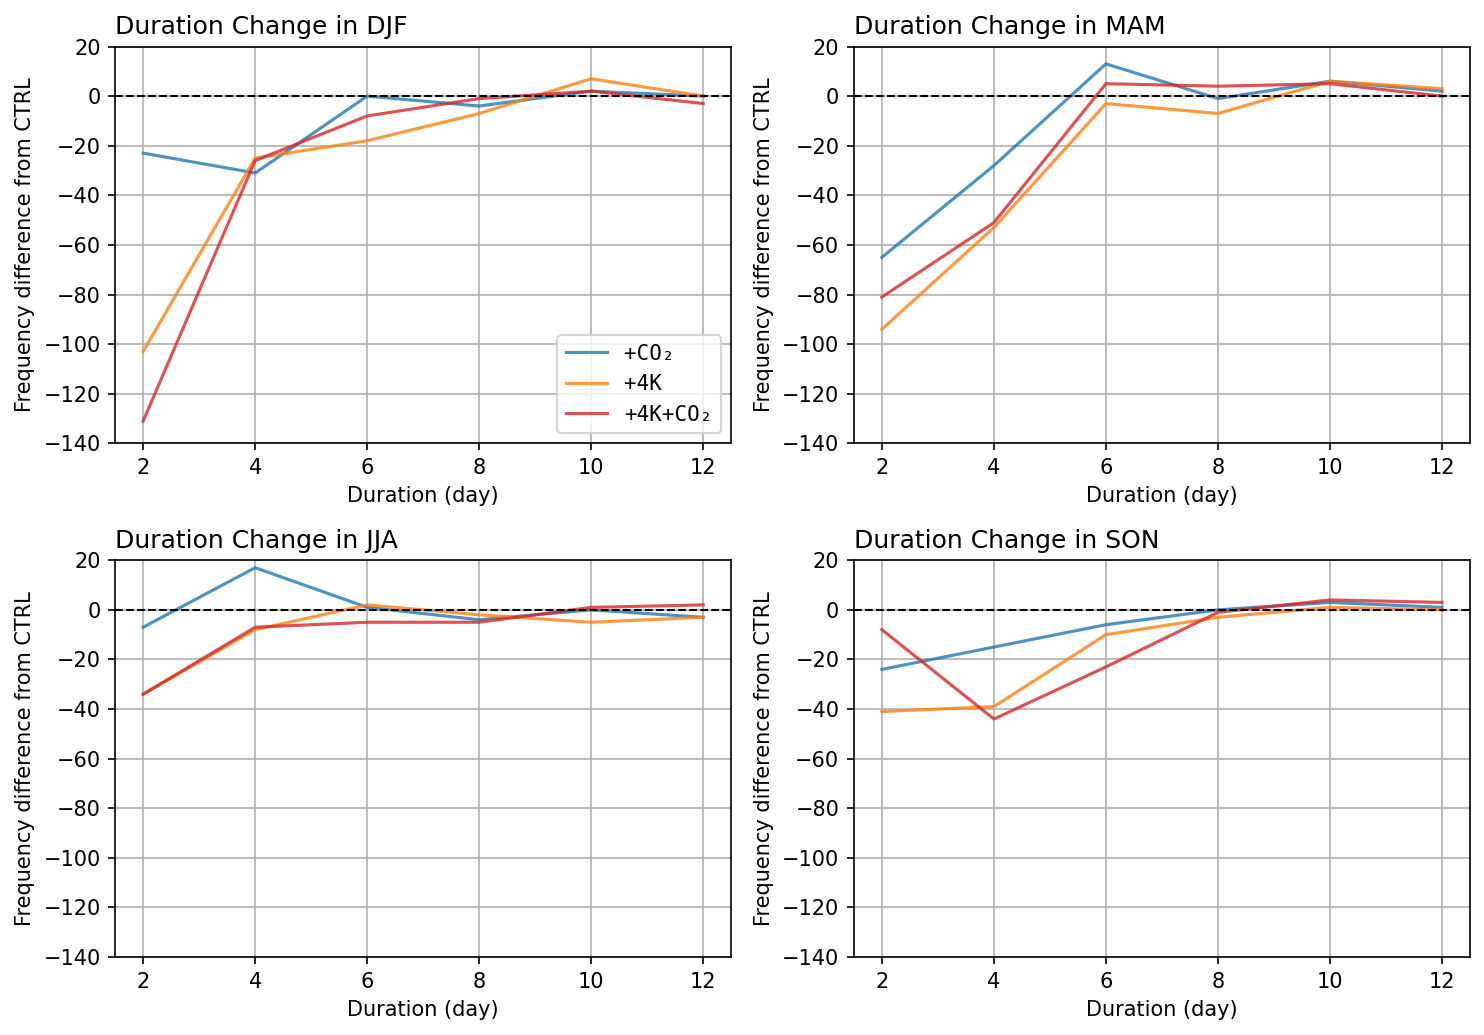

In [29]:
# Plot seasonal duration frequency difference from PIRE
seasons = ['DJF', 'MAM', 'JJA', 'SON']

bins = np.arange(1, 15, 2)
bin_centers = (bins[:-1] + bins[1:]) / 2

fig, axes = plt.subplots(2, 2, figsize=(10, 7), dpi=150)
axes = axes.ravel()

for j, season in enumerate(seasons):
    ax = axes[j]

    h0, _ = np.histogram(durs_season[0][season], bins=bins)

    for i in range(1, len(data)):
        hist, _ = np.histogram(durs_season[i][season], bins=bins)

        ax.plot(
            bin_centers,
            hist - h0,
            color=colorlist[i+1],
            label=expnames[i+1],
            alpha=0.8
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Duration (day)')
    ax.set_ylabel('Frequency difference from CTRL')
    ax.set_title(f'Duration Change in {season}', loc='left')
    ax.set_ylim(-140,20)
    ax.grid()

axes[0].legend(prop={'family': 'monospace'})
plt.tight_layout()
plt.show()

Updated Figure S1 as KDEs

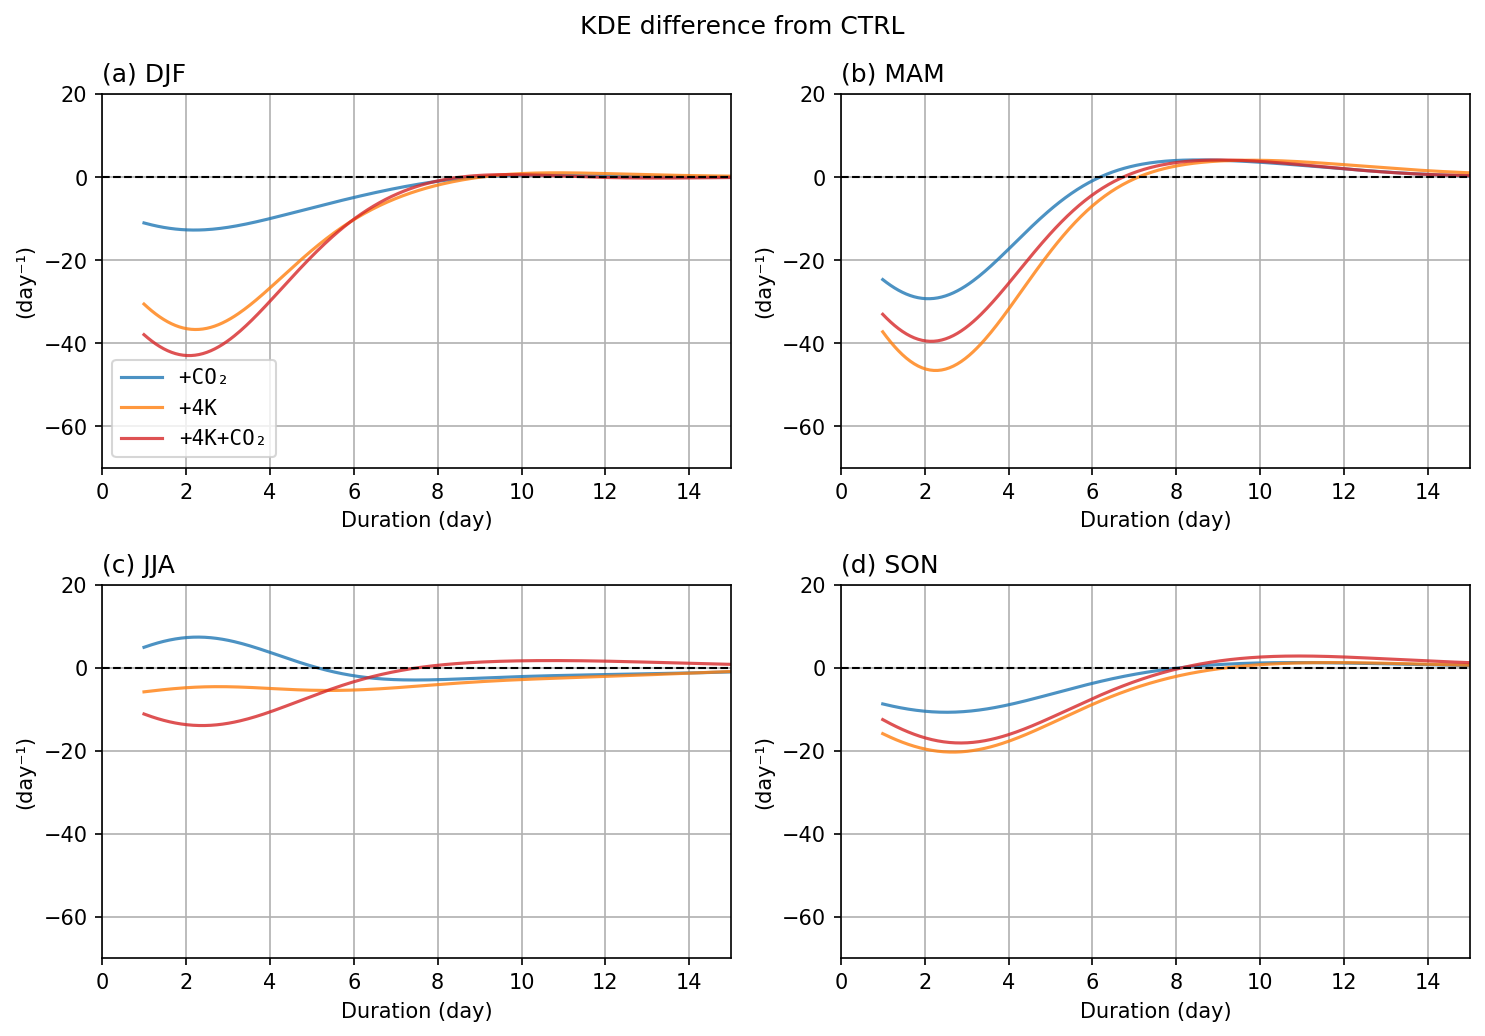

In [34]:
from scipy.stats import gaussian_kde

# Plot seasonal duration KDE-frequency difference from PIRE
seasons = ['DJF', 'MAM', 'JJA', 'SON']

fig, axes = plt.subplots(2, 2, figsize=(10, 7), dpi=150)
axes = axes.ravel()

x_grid = np.linspace(1, 15, 300)
bw_adjust = 4.0   # increase for smoother curves, e.g., 1.2 or 1.5

def duration_kde_frequency(vals, x_grid, bw_adjust=1.0, clip=(1, np.inf)):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if clip is not None:
        vals = vals[(vals >= clip[0]) & (vals <= clip[1])]

    if len(vals) < 2:
        return np.zeros_like(x_grid)

    kde = gaussian_kde(vals)
    kde.set_bandwidth(kde.factor * bw_adjust)

    y = kde(x_grid)

    # mimic seaborn clip: do not show density outside the clipped range
    if clip is not None:
        y[(x_grid < clip[0]) | (x_grid > clip[1])] = 0

    # scale density so the integral over the plotted/clipped range equals sample size
    dx = x_grid[1] - x_grid[0]
    if y.sum() > 0:
        y = y / (y.sum() * dx) * len(vals)

    return y

for j, season in enumerate(seasons):
    ax = axes[j]

    y0 = duration_kde_frequency(
        durs_season[0][season],
        x_grid,
        bw_adjust=bw_adjust
    )

    for i in range(1, len(data)):
        y = duration_kde_frequency(
            durs_season[i][season],
            x_grid,
            bw_adjust=bw_adjust
        )

        ax.plot(
            x_grid,
            y - y0,
            color=colorlist[i+1],
            label=expnames[i+1],
            alpha=0.8
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(0, 15)
    ax.set_xlabel('Duration (day)')
    ax.set_ylabel('(day⁻¹)')
    ax.set_title(f'({"abcd"[j]}) {season}', loc='left')
    ax.set_ylim(-70, 20)
    ax.grid()

axes[0].legend(prop={'family': 'monospace'})
fig.suptitle('KDE difference from CTRL')
plt.tight_layout()
plt.show()

Calculate and plot Figure 2, S2, S3, S4

Compare CTRL with ERA5

In [13]:
# plot full NH
llon = 72
llat = 18
blat = np.linspace(0,90,llat+1)
blon = np.linspace(0,360,llon+1)
v_lat = (blat[1:]+blat[:-1])/2
print(v_lat)

# compute area of each bin for normalization later
area_weight = 2 * np.pi * R**2 * np.abs(np.sin(np.deg2rad(blat[1:])) - np.sin(np.deg2rad(blat[:-1]))) / llon
area_weight = np.zeros((len(area_weight),llon)) + area_weight[:,None]
area_weight.shape

# Addition: compare track density of CTRL with ERA5
ctrl = data[0].copy()
ctrl = ctrl[(ctrl[:,0]>(time_begin*1000000))&(ctrl[:,0]<((time_end+1)*1000000))]
print(ctrl.shape)
month_ctrl, lat_ctrl,lon_ctrl = ctrl[:,0]//10000%100, ctrl[:,1], ctrl[:,2]
era5 = TK.copy()
era5 = era5[(era5[:,0]>(time_begin*1000000))&(era5[:,0]<((time_end+1)*1000000))]
print(era5.shape)
month_era5, lat_era5,lon_era5 = era5[:,0]//10000%100, era5[:,1], era5[:,2]

# month is array of 1-12

[ 2.5  7.5 12.5 17.5 22.5 27.5 32.5 37.5 42.5 47.5 52.5 57.5 62.5 67.5
 72.5 77.5 82.5 87.5]
(41992, 4)
(42376, 4)


42376.0
42376.0
41992.0
41992.0


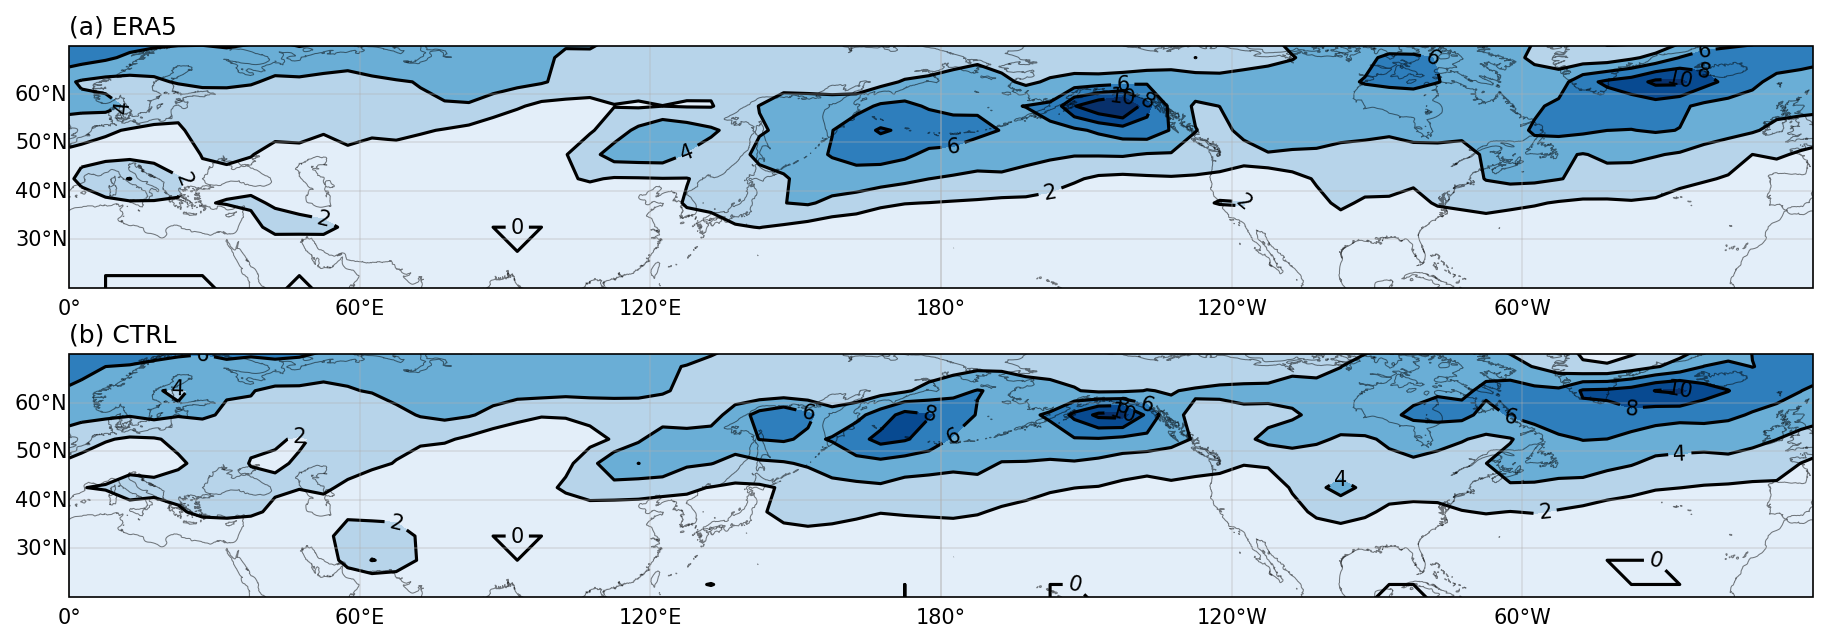

In [14]:
# Addition: compare track density of CTRL with ERA5
letters = 'abcdefg'

month_idx = np.array(np.arange(24),dtype=np.int32)
jlevel = np.linspace(-20,20,11)
jlevel = [j for j in jlevel if j != 0]

dlevel = np.linspace(0,5,6)*2
ddlevel = np.array([-2,-1.5,-1,-0.5,0.5,1,1.5,2])

fig,axes = plt.subplots(2,1,figsize=(15,5),dpi=150,subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})


lat,lon = lat_era5,lon_era5%360
ilat = np.digitize(lat,blat)
ilon = np.digitize(lon,blon)
count = np.zeros((llat,llon))
for i in range(len(lat)):
    count[ilat[i]-1,ilon[i]-1] += 1
print(np.sum(count))
count = filterlat(count,llat,llon,v_lat)
print(np.sum(count))
count /= area_weight
count,lon2 = add_cyclic_point(count,(blon[1:]+blon[:-1])/2)
axes[0].coastlines(linewidth=0.5,alpha=0.5)
cf = axes[0].contourf(lon2,v_lat,count*10000,transform=ccrs.PlateCarree(),cmap='Blues',
    norm=None,levels=dlevel,extend='max')
c = axes[0].contour(lon2,v_lat,count*10000,transform=ccrs.PlateCarree(),colors='black',
    levels=dlevel,extend='both')
axes[0].clabel(c)

lat,lon = lat_ctrl,lon_ctrl%360
ilat = np.digitize(lat,blat)
ilon = np.digitize(lon,blon)
count = np.zeros((llat,llon))
for i in range(len(lat)):
    count[ilat[i]-1,ilon[i]-1] += 1
print(np.sum(count))
count = filterlat(count,llat,llon,v_lat)
print(np.sum(count))
count /= area_weight
count,lon2 = add_cyclic_point(count,(blon[1:]+blon[:-1])/2)
axes[1].coastlines(linewidth=0.5,alpha=0.5)
cf = axes[1].contourf(lon2,v_lat,count*10000,transform=ccrs.PlateCarree(),cmap='Blues',
    norm=None,levels=dlevel,extend='max')
c = axes[1].contour(lon2,v_lat,count*10000,transform=ccrs.PlateCarree(),colors='black',
    levels=dlevel,extend='both')
axes[1].clabel(c)

for ifig in range(2):
    axes[ifig].set_extent([-180,180,20,70],ccrs.PlateCarree())
    axes[ifig].set_title(f'({letters[ifig]}) ' + expnames[ifig],loc='left')#,color=colorlist[ifig+1])
    gl = axes[ifig].gridlines(alpha=0.33)
    gl.left_labels = True
    gl.bottom_labels = True

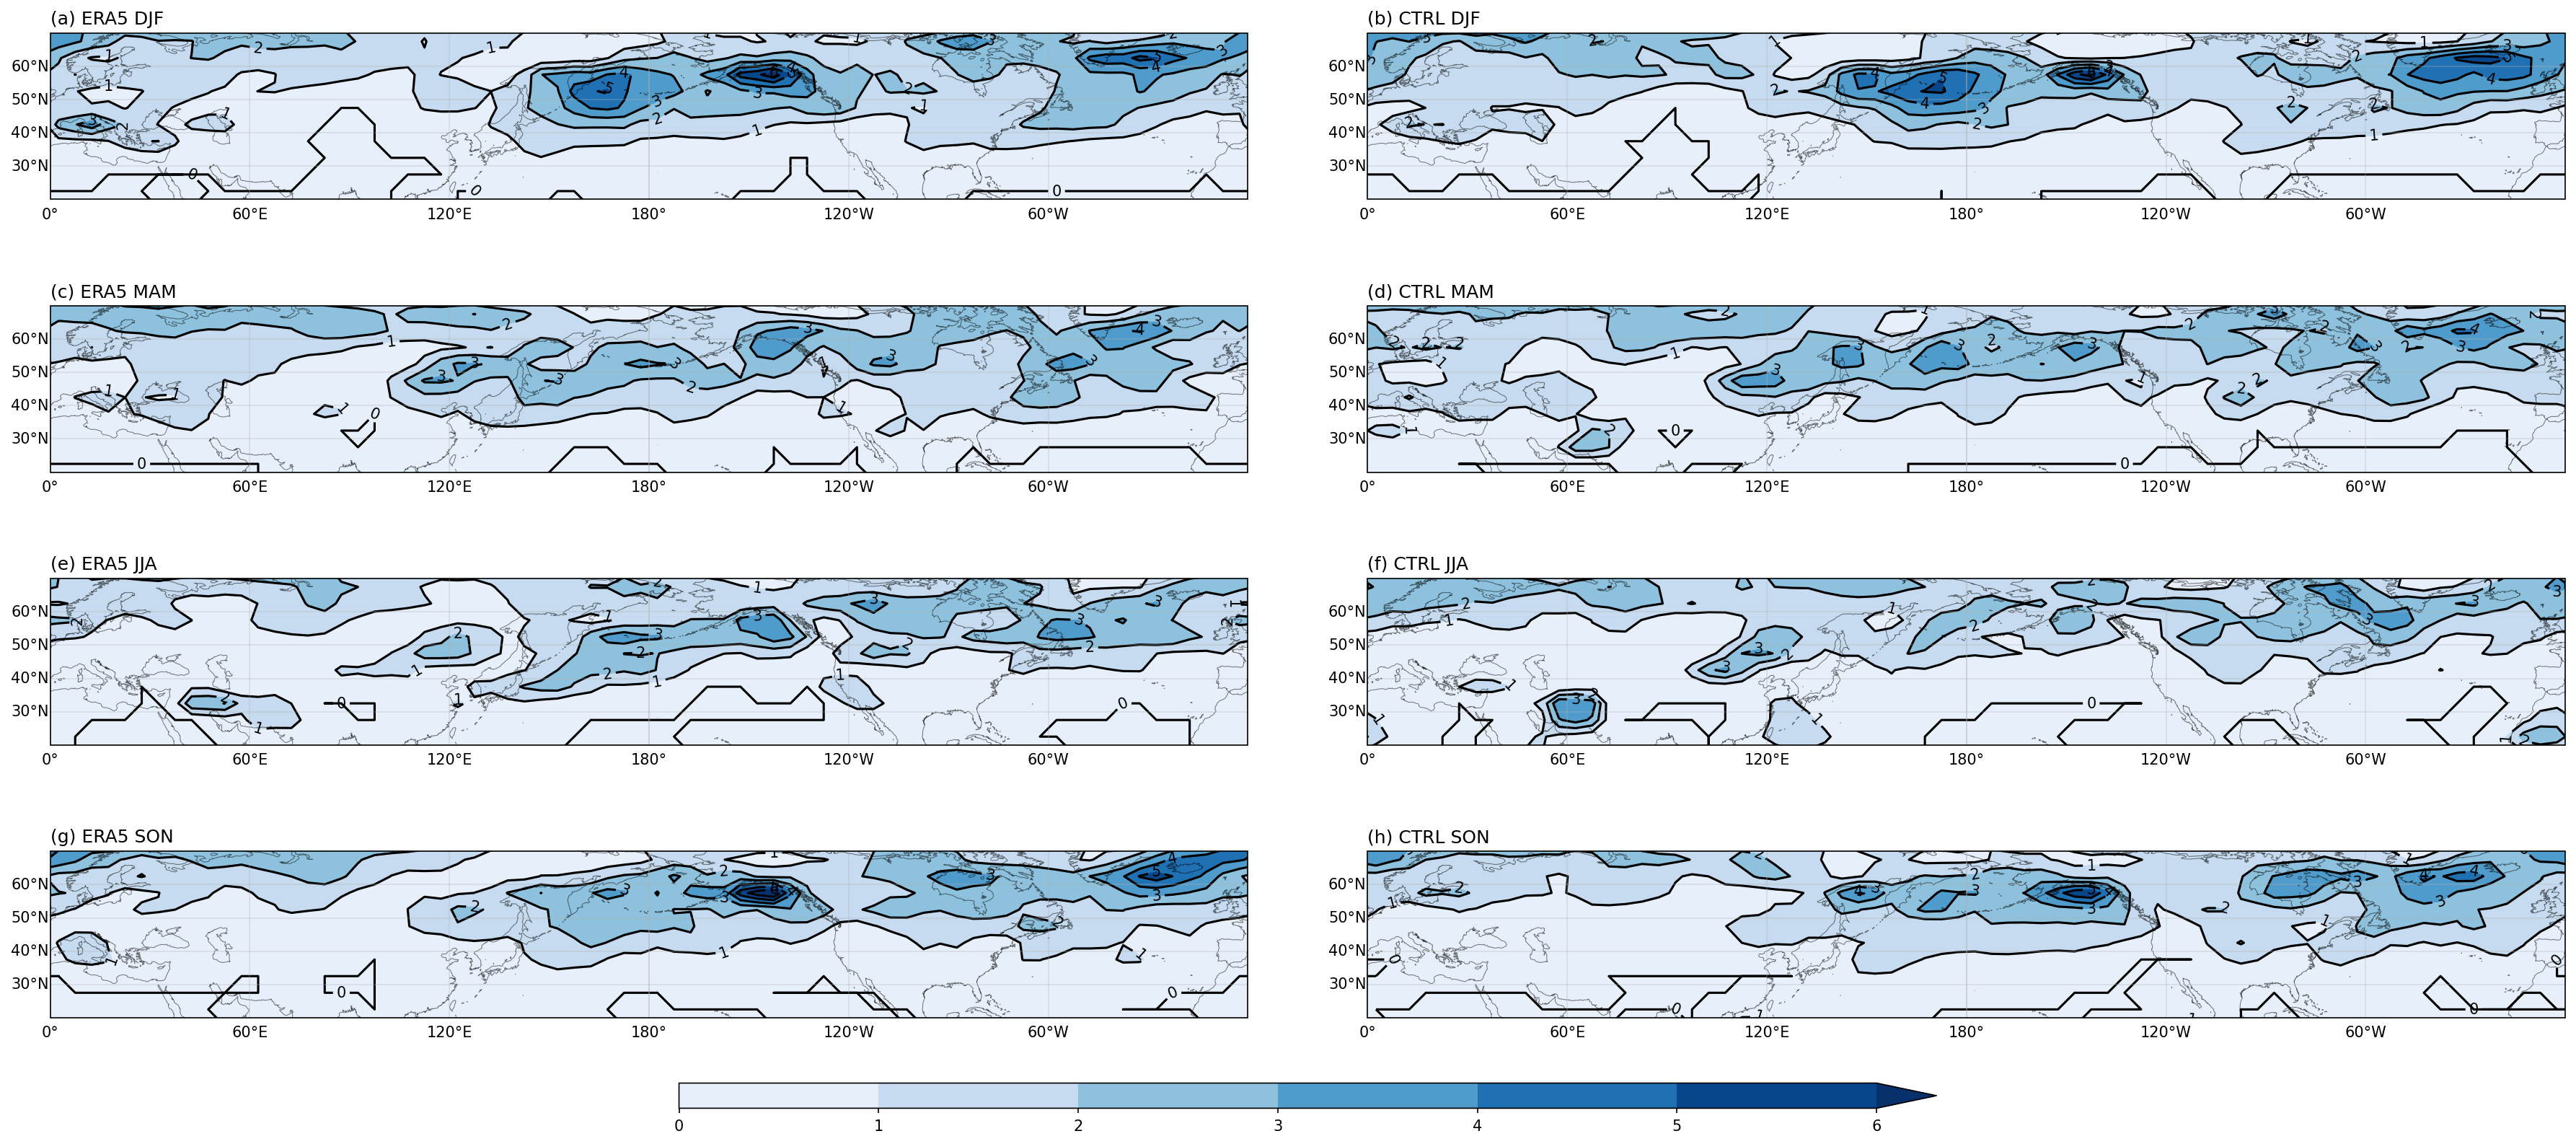

In [15]:
# Addition: compare seasonal track density of CTRL with ERA5
letters = 'abcdefgh'

seasons = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
}

dlevel = [0,1,2,3,4,5,6]

fig, axes = plt.subplots(
    4, 2, figsize=(30, 16), dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)
fig.subplots_adjust(hspace=0.2,wspace=0.1)
def plot_density(ax, lat_all, lon_all, month_all, season_months, title):
    mask = np.isin(month_all, season_months)
    lat, lon = lat_all[mask], lon_all[mask] % 360

    ilat = np.digitize(lat, blat)
    ilon = np.digitize(lon, blon)

    count = np.zeros((llat, llon))
    for i in range(len(lat)):
        if 1 <= ilat[i] <= llat and 1 <= ilon[i] <= llon:
            count[ilat[i]-1, ilon[i]-1] += 1

    count = filterlat(count, llat, llon, v_lat)

    count /= area_weight
    count, lon2 = add_cyclic_point(count, (blon[1:] + blon[:-1]) / 2)

    ax.coastlines(linewidth=0.5, alpha=0.5)
    cf = ax.contourf(
        lon2, v_lat, count * 100000/6,
        transform=ccrs.PlateCarree(),
        cmap='Blues',
        levels=dlevel,
        extend='max'
    )
    c = ax.contour(
        lon2, v_lat, count * 100000/6,
        transform=ccrs.PlateCarree(),
        colors='black',
        levels=dlevel,
        extend='both'
    )
    ax.clabel(c)

    ax.set_extent([-180, 180, 20, 70], ccrs.PlateCarree())
    ax.set_title(title, loc='left')
    gl = ax.gridlines(alpha=0.33)
    gl.left_labels = True
    gl.bottom_labels = True

    return cf


k = 0
for i, (season, months) in enumerate(seasons.items()):
    cf = plot_density(
        axes[i, 0], lat_era5, lon_era5, month_era5, months,
        f'({letters[k]}) ERA5 {season}'
    )
    k += 1

    cf = plot_density(
        axes[i, 1], lat_ctrl, lon_ctrl, month_ctrl, months,
        f'({letters[k]}) CTRL {season}'
    )
    k += 1

fig.colorbar(cf, ax=axes.ravel().tolist(), orientation='horizontal', pad=0.05, aspect=50,shrink=0.5)

Experiment changes from CTRL and seasonality

In [16]:
# use 72 / 15 bins in lon/lat axes
llon = 72
llat = 15
blat = np.linspace(0,75,llat+1)
blon = np.linspace(0,360,llon+1)
v_lat = (blat[1:]+blat[:-1])/2
print(v_lat)

# compute area of each bin for normalization later
area_weight = 2 * np.pi * R**2 * np.abs(np.sin(np.deg2rad(blat[1:])) - np.sin(np.deg2rad(blat[:-1]))) / llon
area_weight = np.zeros((len(area_weight),llon)) + area_weight[:,None]
area_weight.shape

[ 2.5  7.5 12.5 17.5 22.5 27.5 32.5 37.5 42.5 47.5 52.5 57.5 62.5 67.5
 72.5]


(15, 72)

In [17]:
# load U200 for CTRL (dataset inspection, each experiment will be reloaded when plotting)
exp = experiments[0]
folder = f'{u200_dir}/{exp}_monthlymean'
file = [os.path.join(folder,f) for f in os.listdir(folder) if '.nc' in f if 'u200' in f if ('2020' in f or '2021' in f)]
file.sort()
print(len(file))
ds = xr.open_mfdataset(file,concat_dim='month', combine='nested')

24


In [18]:
ds

<xarray.Dataset>
Dimensions:              (grid_yt_coarse: 720, month: 24, bnds: 2,
                          grid_xt_coarse: 1440)
Coordinates:
  * grid_yt_coarse       (grid_yt_coarse) float32 -89.88 -89.62 ... 89.62 89.88
  * grid_xt_coarse       (grid_xt_coarse) float32 0.125 0.375 ... 359.6 359.9
Dimensions without coordinates: month, bnds
Data variables:
    grid_yt_coarse_bnds  (month, grid_yt_coarse, bnds) float32 dask.array<chunksize=(1, 720, 2), meta=np.ndarray>
    grid_xt_coarse_bnds  (month, grid_xt_coarse, bnds) float32 dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    u200_coarse          (month, grid_yt_coarse, grid_xt_coarse) float32 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>

[ 2  3  4  5  6  7  8  9 10 11 12 13 14]
35521.0
35521.0
[0] count shape: (15, 73), valid: 1095
24
(360, 1440)
[ 2  3  4  5  6  7  8  9 10 11 12 13 14]
33666.0
33666.0
[1] count shape: (15, 73), valid: 1095
24
(360, 1440)
[ 2  3  4  5  6  7  8  9 10 11 12 13 14]
30586.0
30586.0
[2] count shape: (15, 73), valid: 1095
24
(360, 1440)
[ 2  3  4  5  6  7  8  9 10 11 12 13 14]
30633.0
30633.0
[3] count shape: (15, 73), valid: 1095
24
(360, 1440)


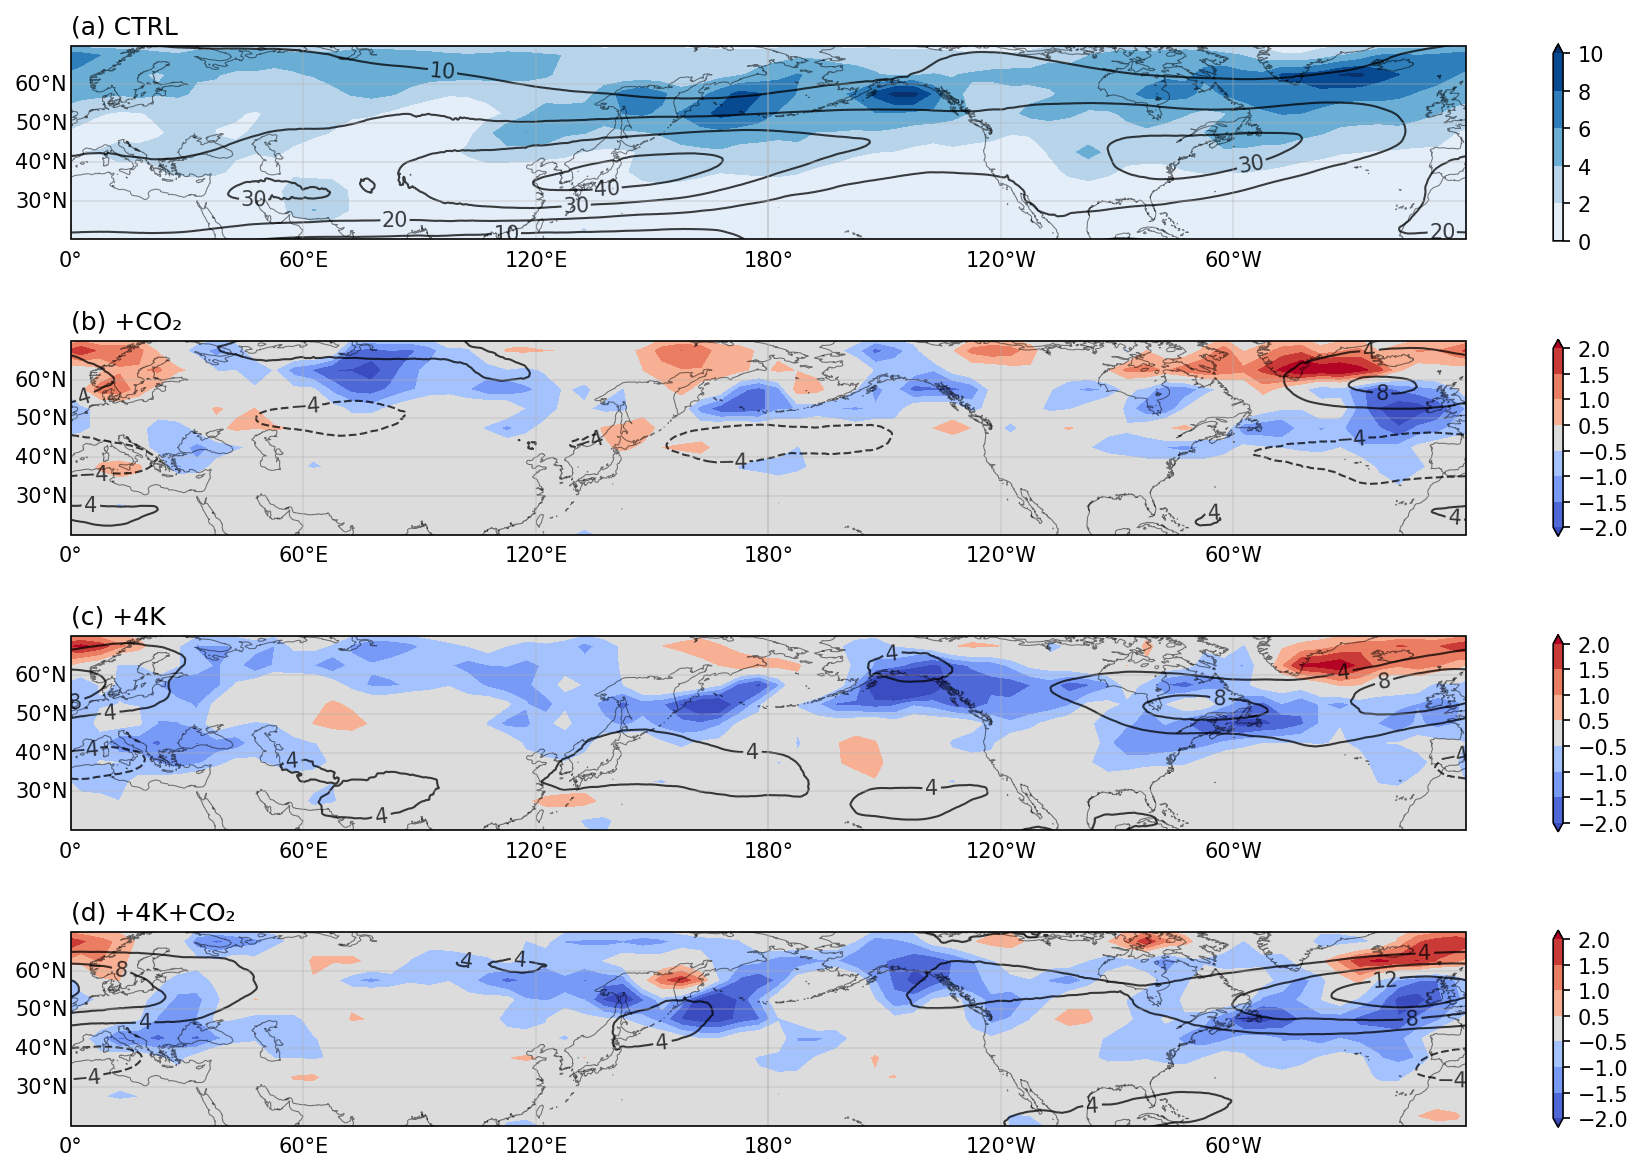

In [19]:
# Figure 2 plotting
letters = 'abcdefg'

month_idx = np.array(np.arange(24),dtype=np.int32) # two years of data, start in Jan and end in Dec
jlevel = np.linspace(-20,20,11)
jlevel = [j for j in jlevel if j != 0]

dlevel = np.linspace(0,5,6)*2
ddlevel = np.array([-2,-1.5,-1,-0.5,0.5,1,1.5,2])

fig,axes = plt.subplots(4,1,figsize=(15,10),dpi=150,subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})


for jfig, dd in enumerate(data):
    ifig = jfig

    # calc density map:
    #   get all samples in 2020-2021 (not only MCs as the map covers larger latitude range and to show storm track shift)
    #   count frequency in each bin
    #   apply some smoothing (wider rolling window size at higher latitude proportional to 1/cos(lat), total count not changed)
    #   normalize by area of each bin

    dd = dd[(dd[:,0]>(time_begin*1000000))&(dd[:,0]<((time_end+1)*1000000)),:]
    dd = dd[dd[:,1] < 70]
    lat,lon = dd[:,1], dd[:,2]
    ilat = np.digitize(lat,blat)
    print(np.unique(ilat))
    
    ilon = np.digitize(lon,blon)
    count = np.zeros((llat,llon))
    for i in range(len(lat)):
        count[ilat[i]-1,ilon[i]-1] += 1
    print(np.sum(count))
    count = filterlat(count,llat,llon,v_lat)
    print(np.sum(count))
    count /= area_weight

    count,lon2 = add_cyclic_point(count,(blon[1:]+blon[:-1])/2)

    #print(count.shape)
    axes[ifig].coastlines(linewidth=0.5,alpha=0.5)

    exp = experiments[jfig]

    if jfig == 0: # CTRL and total field
        count0 = count.copy()
        
        print(f'[{ifig}] count shape: {count0.shape}, valid: {np.isfinite(count0).sum()}')

        cf = axes[ifig].contourf(lon2,v_lat,count0*10000,transform=ccrs.PlateCarree(),cmap='Blues',
            norm=None,levels=dlevel,extend='max')

        exp = experiments[0]
        folder = f'{u200_dir}/{exp}_monthlymean'
        file = [os.path.join(folder,f) for f in os.listdir(folder) if '.nc' in f if 'u200' in f if ('2020' in f or '2021' in f)]
        file.sort()
        print(len(file))
        ds = xr.open_mfdataset(file,concat_dim='month', combine='nested')
        dmon0 = ds['u200_coarse'].sel(month=month_idx).values.mean(axis=0)[360:]
        #print(dmon0)
        print(dmon0.shape)
        #break

        cu = axes[0].contour(np.linspace(0.125,359.875,1440),np.linspace(0.125,89.875,360),dmon0,transform=ccrs.PlateCarree(),
            colors='black',levels=np.linspace(0,80,9),linewidths=1,alpha=0.75)
        
        axes[ifig].clabel(cu)

        plt.colorbar(cf,ax=axes[ifig],shrink=0.8)

    else: # sensitivity experiments and perturbed fields
        
        print(f'[{ifig}] count shape: {count.shape}, valid: {np.isfinite(count).sum()}')

        cf = axes[ifig].contourf(lon2,v_lat,(count-count0)*10000,transform=ccrs.PlateCarree(),cmap='coolwarm',
            norm=None,levels=ddlevel,extend='both')

        folder = f'{u200_dir}/{exp}_monthlymean'
        file = [os.path.join(folder,f) for f in os.listdir(folder) if '.nc' in f if 'u200' in f if ('2020' in f or '2021' in f)]
        file.sort()
        print(len(file))
        ds = xr.open_mfdataset(file,concat_dim='month', combine='nested')
        dmon = ds['u200_coarse'].sel(month=month_idx).values.mean(axis=0)[360:]
        print(dmon.shape)

        cu = axes[ifig].contour(np.linspace(0.125,359.875,1440),np.linspace(0.125,89.875,360),(dmon-dmon0),transform=ccrs.PlateCarree(),
            colors='black',levels=jlevel,linewidths=1,alpha=0.75)

        axes[ifig].clabel(cu)
        plt.colorbar(cf,ax=axes[ifig],shrink=0.8)

    axes[ifig].set_extent([-180,180,20,70],ccrs.PlateCarree())
    #plt.colorbar(cf,ax=axes[label])
    
    axes[ifig].set_title(f'({letters[ifig]}) ' + expnames[ifig+1],loc='left')#,color=colorlist[ifig+1])
    gl = axes[ifig].gridlines(alpha=0.33)
    gl.left_labels = True
    gl.bottom_labels = True

# since multiplied density by 10000 during plotting, unit of density is count per 10000 km^2


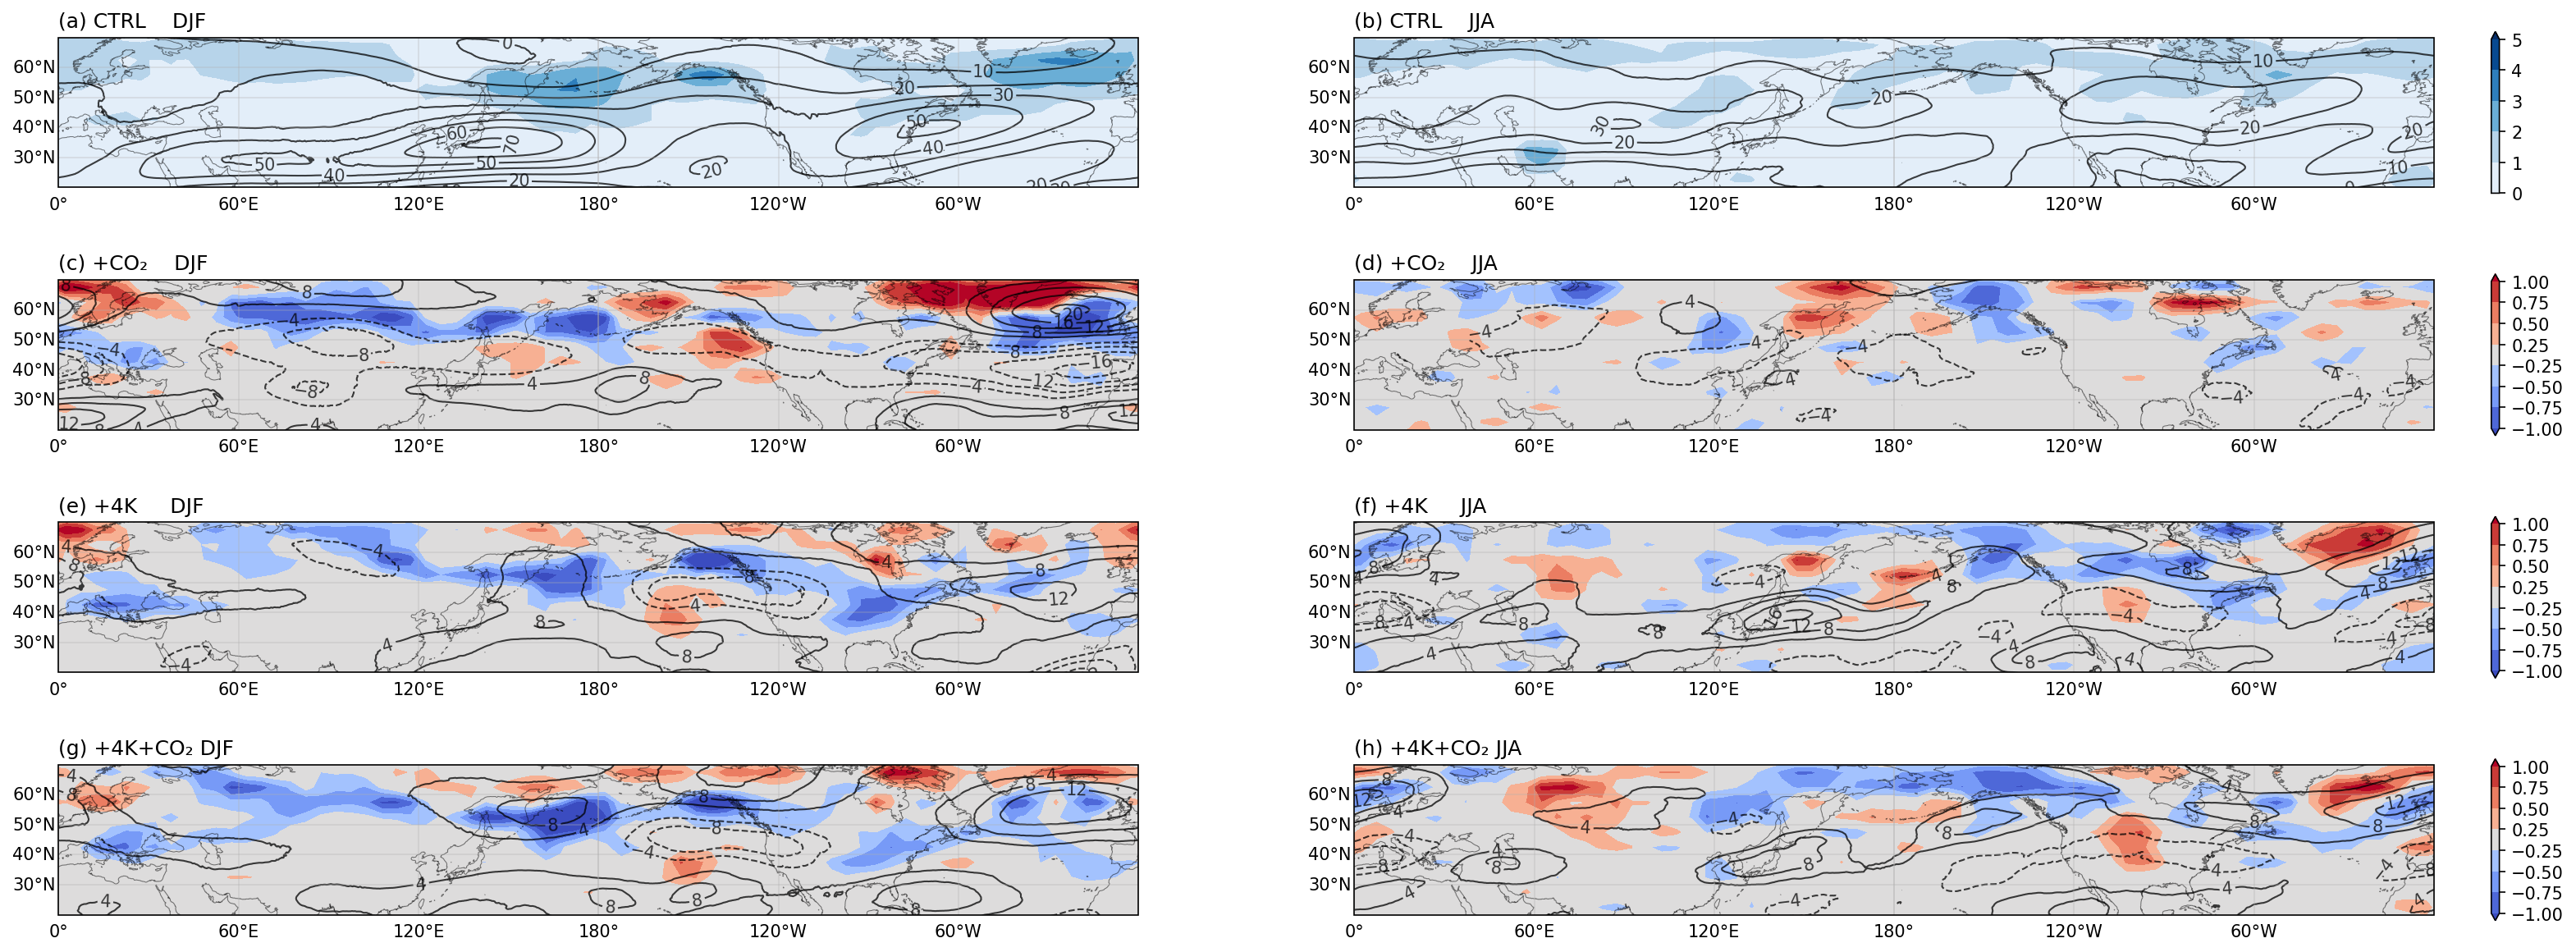

In [20]:
letters = 'abcdefgh'

seasons = {
    'DJF': {'months': [12, 1, 2], 'month_idx': [0, 1, 11, 12, 13, 23]},
    'JJA': {'months': [6, 7, 8],  'month_idx': [5, 6, 7, 17, 18, 19]},
}

jlevel = [j for j in np.linspace(-20, 20, 11) if j != 0]
dlevel = np.linspace(0, 5, 6) * 2 / 2
ddlevel = np.array([-2, -1.5, -1, -0.5, 0.5, 1, 1.5, 2]) / 2

fig, axes = plt.subplots(
    4, 2, figsize=(30, 10), dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)

def get_density(dd, season_months):
    dd = dd[(dd[:,0] > time_begin*1000000) & (dd[:,0] < (time_end+1)*1000000), :]
    dd = dd[dd[:,1] < 70]

    month = (dd[:,0] // 10000) % 100
    dd = dd[np.isin(month, season_months)]

    lat, lon = dd[:,1], dd[:,2]
    ilat = np.digitize(lat, blat)
    ilon = np.digitize(lon, blon)

    count = np.zeros((llat, llon))
    for ii in range(len(lat)):
        if 1 <= ilat[ii] <= llat and 1 <= ilon[ii] <= llon:
            count[ilat[ii]-1, ilon[ii]-1] += 1

    count = filterlat(count, llat, llon, v_lat)
    count /= area_weight
    count, lon2 = add_cyclic_point(count, (blon[1:] + blon[:-1]) / 2)

    return count, lon2

def get_u200(exp, month_idx):
    folder = f'{u200_dir}/{exp}_monthlymean'
    file = [
        os.path.join(folder, f) for f in os.listdir(folder)
        if '.nc' in f and 'u200' in f and ('2020' in f or '2021' in f)
    ]
    file.sort()

    ds = xr.open_mfdataset(file, concat_dim='month', combine='nested')
    return ds['u200_coarse'].isel(month=month_idx).values.mean(axis=0)[360:]

for icol, (season, sinfo) in enumerate(seasons.items()):

    count0, lon2 = get_density(data[0], sinfo['months'])
    dmon0 = get_u200(experiments[0], sinfo['month_idx'])

    for jfig, dd in enumerate(data[:4]):

        ax = axes[jfig, icol]
        exp = experiments[jfig]

        count, lon2 = get_density(dd, sinfo['months'])
        dmon = get_u200(exp, sinfo['month_idx'])

        ax.coastlines(linewidth=0.5, alpha=0.5)

        if jfig == 0:
            cf = ax.contourf(
                lon2, v_lat, count0 * 10000,
                transform=ccrs.PlateCarree(),
                cmap='Blues',
                levels=dlevel,
                extend='max'
            )

            cu = ax.contour(
                np.linspace(0.125, 359.875, 1440),
                np.linspace(0.125, 89.875, 360),
                dmon0,
                transform=ccrs.PlateCarree(),
                colors='black',
                levels=np.linspace(0, 80, 9),
                linewidths=1,
                alpha=0.75
            )

        else:
            cf = ax.contourf(
                lon2, v_lat, (count - count0) * 10000,
                transform=ccrs.PlateCarree(),
                cmap='coolwarm',
                levels=ddlevel,
                extend='both'
            )

            cu = ax.contour(
                np.linspace(0.125, 359.875, 1440),
                np.linspace(0.125, 89.875, 360),
                dmon - dmon0,
                transform=ccrs.PlateCarree(),
                colors='black',
                levels=jlevel,
                linewidths=1,
                alpha=0.75
            )

        ax.clabel(cu)
        ax.set_extent([-180, 180, 20, 70], ccrs.PlateCarree())

        ax.set_title(
            f'({letters[jfig*2+icol]}) {expnames[jfig+1]} {season}',
            loc='left'
        )

        gl = ax.gridlines(alpha=0.33)
        gl.left_labels = True
        gl.bottom_labels = True

        # one colorbar on right side of each row
        if icol == 1:
            cb = fig.colorbar(cf, ax=axes[jfig, :], shrink=0.8, pad=0.02)


Figure R1-11

PIRE u925: 24 v925: 24


[0] wind925 shape: (360, 1440)
PIRE_CO2_1270ppmv u925: 24 v925: 24
[1] wind925 shape: (360, 1440)
PIRE_PLUS_4K u925: 24 v925: 24
[2] wind925 shape: (360, 1440)
PIRE_PLUS_4K_CO2_1270ppmv u925: 24 v925: 24
[3] wind925 shape: (360, 1440)


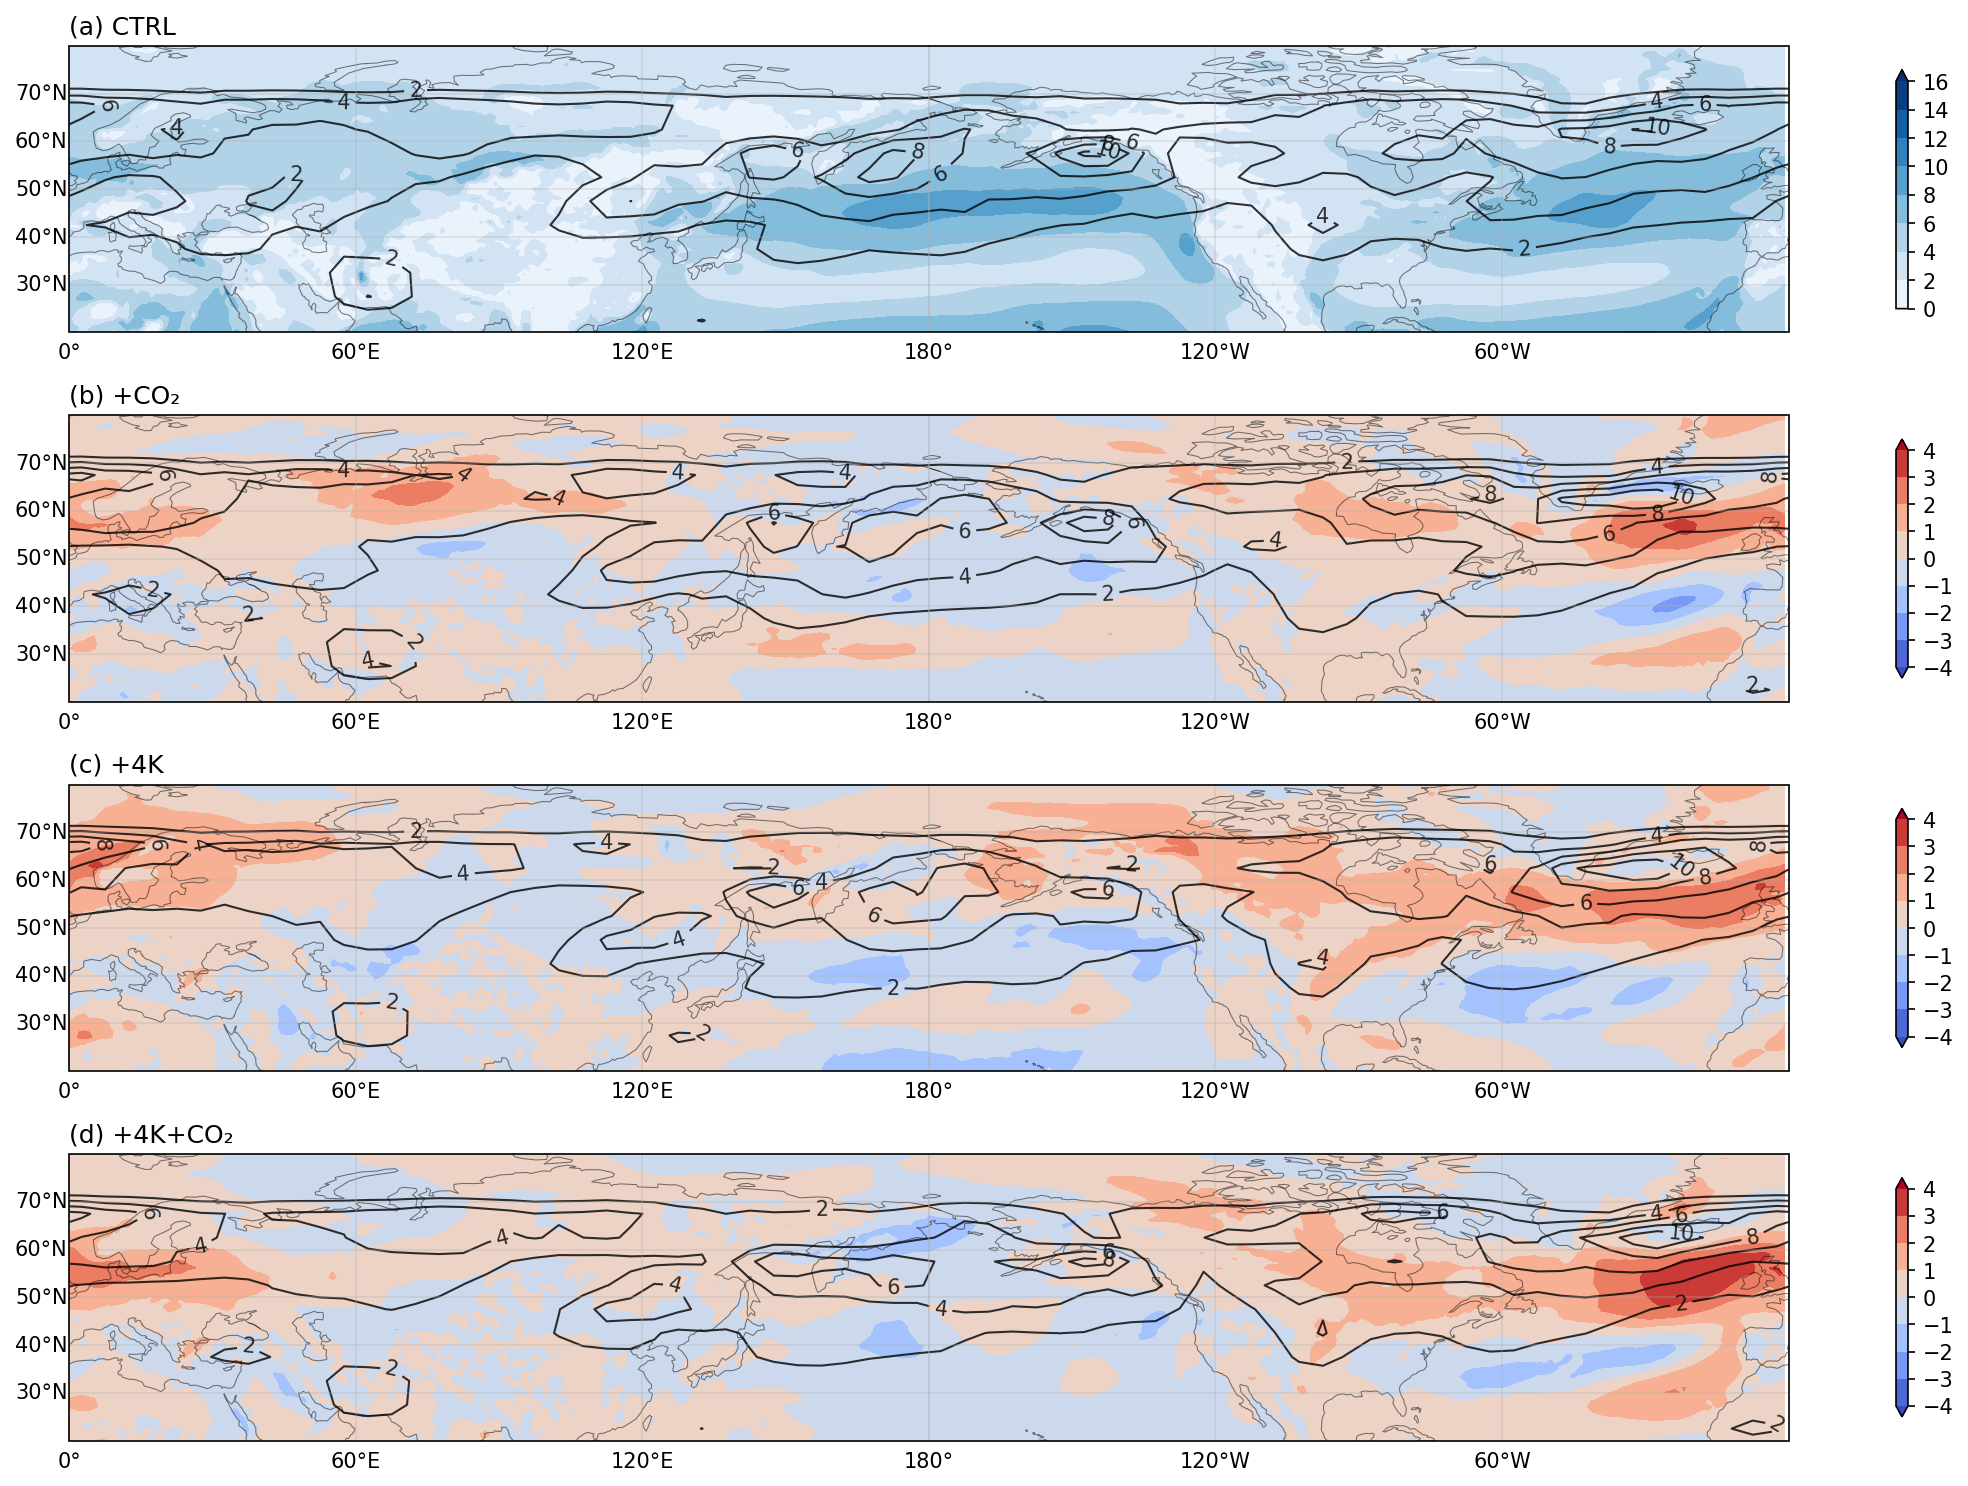

In [21]:
# 925-hPa wind speed plotting with superimposed track density contours

letters = 'abcdefg'

month_idx = np.array(np.arange(24), dtype=np.int32)

# wind speed levels, unit: m s-1
wlevel = np.linspace(0, 16, 9)
dwlevel = np.linspace(-4, 4, 9)

# track density contour levels
track_levels = np.linspace(2, 10, 5)

fig, axes = plt.subplots(
    4, 1,
    figsize=(15, 10),
    dpi=150,
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)

lon = np.linspace(0.125, 359.875, 1440)
lat = np.linspace(0.125, 89.875, 360)

uv925_dir = '/data/keeling/a/mingshi3/c/xshield/metfields'


def get_wind925(exp, month_idx):

    folder = f'{uv925_dir}/{exp}_monthlymean'

    ufile = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if '.nc' in f and 'u925' in f and ('2020' in f or '2021' in f)
    ]

    vfile = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if '.nc' in f and 'v925' in f and ('2020' in f or '2021' in f)
    ]

    ufile.sort()
    vfile.sort()

    print(exp, 'u925:', len(ufile), 'v925:', len(vfile))

    dsu = xr.open_mfdataset(ufile, concat_dim='month', combine='nested')
    dsv = xr.open_mfdataset(vfile, concat_dim='month', combine='nested')

    u = dsu['u925_coarse'].isel(month=month_idx).values[:, 360:, :]
    v = dsv['v925_coarse'].isel(month=month_idx).values[:, 360:, :]

    wspd = np.sqrt(u**2 + v**2).mean(axis=0)

    dsu.close()
    dsv.close()

    return wspd


def get_track_density(dd):

    dd = dd[
        (dd[:,0] > (time_begin * 1000000)) &
        (dd[:,0] < ((time_end + 1) * 1000000))
    ]

    dd = dd[dd[:,1] < 70]

    lat0 = dd[:,1]
    lon0 = dd[:,2] % 360

    ilat = np.digitize(lat0, blat)
    ilon = np.digitize(lon0, blon)

    count = np.zeros((llat, llon))

    for i in range(len(lat0)):
        count[ilat[i]-1, ilon[i]-1] += 1

    count = filterlat(count, llat, llon, v_lat)
    count /= area_weight

    count, lon2 = add_cyclic_point(
        count,
        (blon[1:] + blon[:-1]) / 2
    )

    return count * 10000, lon2


for jfig, exp in enumerate(experiments[:4]):

    ifig = jfig

    axes[ifig].coastlines(linewidth=0.5, alpha=0.5)

    # wind speed
    dmon = get_wind925(exp, month_idx)
    print(f'[{ifig}] wind925 shape:', dmon.shape)

    # track density
    count, lon2 = get_track_density(data[jfig])

    if jfig == 0:

        dmon0 = dmon.copy()

        cf = axes[ifig].contourf(
            lon[::4],
            lat[::4],
            dmon0[::4, ::4],
            transform=ccrs.PlateCarree(),
            cmap='Blues',
            levels=wlevel,
            extend='max'
        )

        # superimposed track density contour
        ct = axes[ifig].contour(
            lon2,
            v_lat,
            count,
            transform=ccrs.PlateCarree(),
            colors='black',
            linewidths=1,
            levels=track_levels,
            alpha=0.8
        )

        axes[ifig].clabel(ct)

        plt.colorbar(cf, ax=axes[ifig], shrink=0.8)

    else:

        cf = axes[ifig].contourf(
            lon[::4],
            lat[::4],
            (dmon - dmon0)[::4, ::4],
            transform=ccrs.PlateCarree(),
            cmap='coolwarm',
            levels=dwlevel,
            extend='both'
        )

        # superimposed original track density
        ct = axes[ifig].contour(
            lon2,
            v_lat,
            count,
            transform=ccrs.PlateCarree(),
            colors='black',
            linewidths=1,
            levels=track_levels,
            alpha=0.8
        )

        axes[ifig].clabel(ct)

        plt.colorbar(cf, ax=axes[ifig], shrink=0.8)

    axes[ifig].set_extent(
        [-180, 180, 20, 80],
        ccrs.PlateCarree()
    )

    axes[ifig].set_title(
        f'({letters[ifig]}) ' + expnames[ifig + 1],
        loc='left'
    )

    gl = axes[ifig].gridlines(alpha=0.33)
    gl.left_labels = True
    gl.bottom_labels = True

plt.tight_layout()
plt.show()